# Customer Churn – Exploratory Data Analysis & Feature Preparation

## Objective
Analyze customer churn data to understand patterns, clean the dataset,
and prepare features for future machine learning models.

## Dataset
Telco churn dataset (CSV format)

## Tools
Python, Pandas, NumPy, Matplotlib

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load Dataset
df = pd.read_csv("telco[1].csv")
df.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [3]:
# Basic Inspection
df.shape
df.info()
df.isnull().sum().sort_values(ascending=False).head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   object 
 4   Senior Citizen                     7043 non-null   object 
 5   Married                            7043 non-null   object 
 6   Dependents                         7043 non-null   object 
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   object 
 9   State                              7043 non-null   object 
 10  City                               7043 non-null   object 
 11  Zip Code                           7043 non-null   int64

,0
Churn Reason,5174
Churn Category,5174
Offer,3877
Internet Type,1526
Senior Citizen,0
Married,0
Age,0
Under 30,0
Country,0
State,0


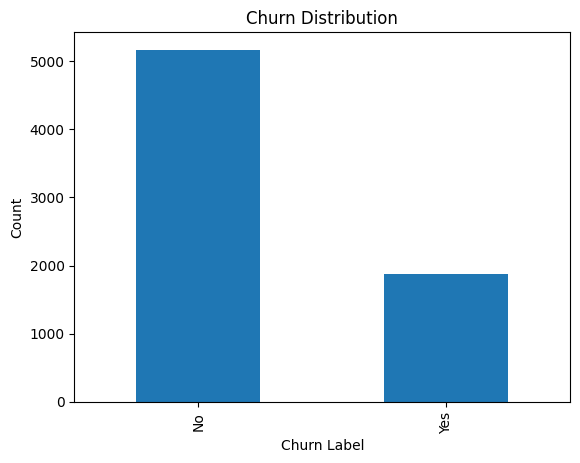

In [4]:
# Target variable analysis
df['Churn Label'].value_counts()
df['Churn Label'].value_counts().plot(kind='bar')
plt.title("Churn Distribution")
plt.xlabel("Churn Label")
plt.ylabel("Count")
plt.show()

### Insight: Churn Distribution

- Majority of customers did not churn.
- The dataset is slightly imbalanced.
- Churn Label will be used as the target variable for modeling.

In [5]:
# Numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols

Index(['Age', 'Number of Dependents', 'Zip Code', 'Latitude', 'Longitude',
       'Population', 'Number of Referrals', 'Tenure in Months',
       'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download',
       'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Satisfaction Score', 'Churn Score', 'CLTV'],
      dtype='object')

In [6]:
# Handle missing values
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

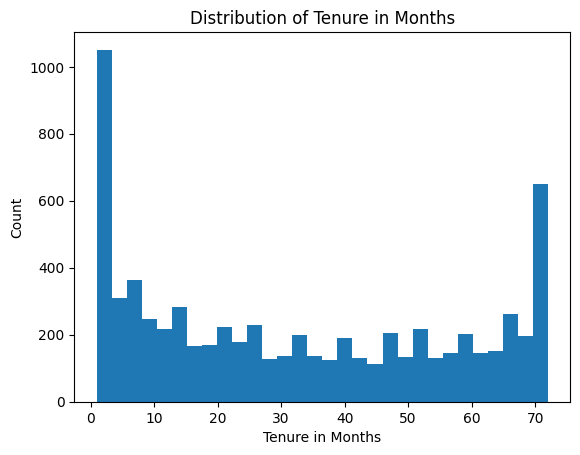

In [7]:
# Tenure analysis
plt.hist(df['Tenure in Months'], bins=30)
plt.title("Distribution of Tenure in Months")
plt.xlabel("Tenure in Months")
plt.ylabel("Count")
plt.show()

### Insight: Tenure and Churn

- Most customers have lower tenure values.
- Customers with shorter tenure are more likely to churn.
- Tenure is a strong predictor of customer retention.

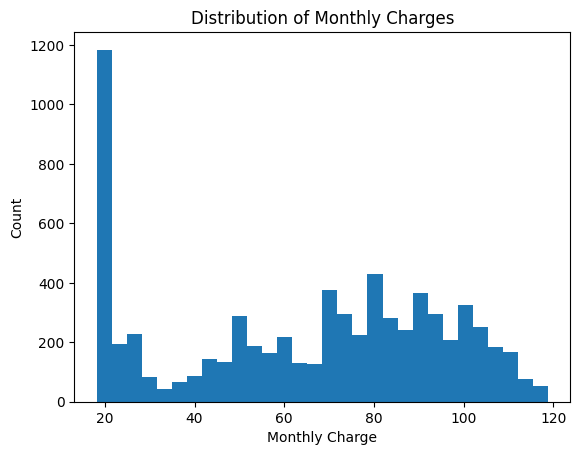

In [8]:
# Monthly Charge analysis
plt.hist(df['Monthly Charge'], bins=30)
plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charge")
plt.ylabel("Count")
plt.show()

### Insight: Monthly Charges

- Higher monthly charges appear more frequently among churned customers.
- Pricing may influence churn behavior.

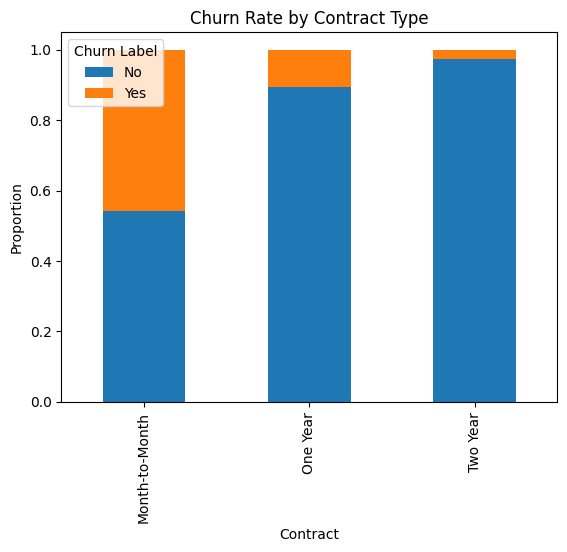

In [9]:
# Contract vs Churn
contract_churn = (
    df.groupby('Contract')['Churn Label']
      .value_counts(normalize=True)
      .unstack()
)

contract_churn.plot(kind='bar', stacked=True)
plt.title("Churn Rate by Contract Type")
plt.ylabel("Proportion")
plt.show()

### Insight: Contract Type

- Month-to-month contracts show the highest churn rate.
- Long-term contracts reduce churn significantly.

In [10]:
# Encoding
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.shape

(7043, 8220)

In [11]:
# Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

## Conclusion

- Performed exploratory data analysis on customer churn data
- Identified tenure, contract type, and monthly charge as key churn drivers
- Cleaned and prepared data for machine learning models

